# Interoperability with R
Reading Anndata objects stored in .hdf5 format into R is fairly simple. 

In R there are two primary packages used to deal with Single Cell data. SingleCellExperiment objects and Seurat objects.

The following table compares the these.

| Data Component         | AnnData           | SingleCellExperiment               | Seurat                                                                       |
| ---------------------- | ------------------| ---------------------------------- | ---------------------------------------------------------------------------- |
| Count matrix           | `adata.X`         | `assay(sce, "counts")`             | `GetAssayData(seurat, layer = "counts")`                                     |
| Multiple assays/layers | `adata.layers`    | `assays(sce)`                      | `seurat@assays`                                                              |
| Cell metadata          | `adata.obs`       | `colData(sce)`                     | `seurat@meta.data`                                                           |
| Gene metadata          | `adata.var`       | `rowData(sce)`                     | `seurat[["RNA"]]@meta.features`                                              |
| Embeddings             | `adata.obsm`      | `reducedDims(sce)`                 | `Embeddings(seurat, "pca")`, `Embeddings(seurat, "umap")`, etc.              |
| Unstructured metadata  | `adata.uns`       | `metadata(sce)`                    | `seurat@misc`                                                                |

In [1]:
%load_ext rpy2.ipython

## Reading .hdf5 files into R

In [2]:
%%R
library(anndataR)
library(scater)

h5ad_path <- "../results/adata/09-annotation.h5ad"

# as `SingleCellExperiment` object 
sce <- read_h5ad(h5ad_path, as = "SingleCellExperiment")

# Or as Seurat object
# seurat <- read_h5ad(h5ad_path, as = "Seurat")

Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

## Exploring the `SingleCellExperiment` object

After reading, the slots from `AnnData` are mapped to their SCE equivalents.

In [3]:
%%R

# adata.X  →  assay(sce, "X")  (count / normalized matrix)
dim(assay(sce, "X"))       # genes x cells

[1] 32253 23906


In [4]:
%%R

# adata.obs  →  colData(sce)  (cell-level metadata)
head(colData(sce))

DataFrame with 6 rows and 31 columns
                   sample      day scdblfinder_score scdblfinder_class
                 <factor> <factor>         <numeric>         <integer>
AAACCTGCAATGGAAT     D2_C        2        0.11076372                 1
AAACCTGCACCAACCG     D2_C        2        0.09374205                 1
AAACCTGCACCTGGTG     D2_C        2        0.00909069                 1
AAACCTGCACGCCAGT     D2_C        2        0.00371124                 1
AAACCTGCAGACAGGT     D2_C        2        0.00179863                 1
AAACCTGCAGTAGAGC     D2_C        2        0.22666755                 1
                 n_genes_by_counts log1p_n_genes_by_counts total_counts
                         <integer>               <numeric>    <integer>
AAACCTGCAATGGAAT              2526                 7.83479         8176
AAACCTGCACCAACCG              2570                 7.85205         7931
AAACCTGCACCTGGTG              2378                 7.77444         5491
AAACCTGCACGCCAGT              1485 

In [5]:
%%R

# adata.var  →  rowData(sce)  (gene-level metadata)
head(rowData(sce))

DataFrame with 6 rows and 16 columns
               mt      ribo        hb n_cells_by_counts mean_counts
        <logical> <logical> <logical>         <integer>   <numeric>
Gm7449      FALSE     FALSE     FALSE                76  0.00224427
Gm29155     FALSE     FALSE     FALSE                39  0.00115167
Gm29157     FALSE     FALSE     FALSE               175  0.00566974
Gm8141      FALSE     FALSE     FALSE               360  0.01080794
Exo1        FALSE     FALSE     FALSE               437  0.01582802
Uxs1        FALSE     FALSE     FALSE              7066  0.28732577
        log1p_mean_counts pct_dropout_by_counts total_counts log1p_total_counts
                <numeric>             <numeric>    <integer>          <numeric>
Gm7449         0.00224176               99.7756           76            4.34381
Gm29155        0.00115100               99.8848           39            3.68888
Gm29157        0.00565373               99.4832          192            5.26269
Gm8141         0.01

In [6]:
%%R

# adata.obsm  →  reducedDims(sce)  (embeddings: PCA, UMAP, …)
reducedDimNames(sce)

[1] "X_pca"         "X_pca_harmony" "X_umap"       


## Plotting the UMAP with Scater

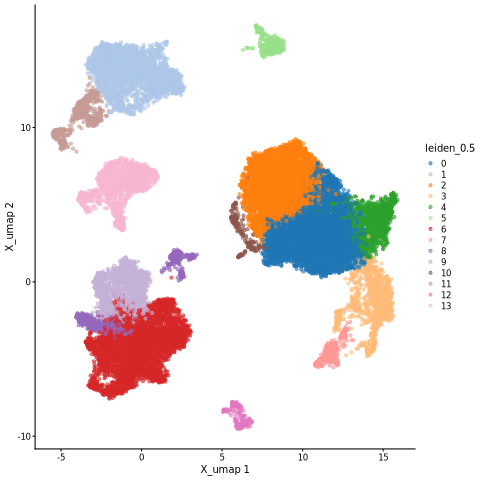

In [7]:
%%R

plotUMAP(sce, colour_by = "leiden_0.5", dimred = "X_umap")

## Writing a `SingleCellExperiment` back to `.h5ad`

`write_h5ad` performs the reverse conversion, producing an `.h5ad` readable by scanpy.

In [8]:
%%R

write_h5ad(sce, "tmp.h5ad")

You created a large dataset with compression and chunking.
The chunk size is equal to the dataset dimensions.
If you want to read subsets of the dataset, you should testsmaller chunk sizes to improve read times.
You created a large dataset with compression and chunking.
The chunk size is equal to the dataset dimensions.
If you want to read subsets of the dataset, you should testsmaller chunk sizes to improve read times.
You created a large dataset with compression and chunking.
The chunk size is equal to the dataset dimensions.
If you want to read subsets of the dataset, you should testsmaller chunk sizes to improve read times.
You created a large dataset with compression and chunking.
The chunk size is equal to the dataset dimensions.
If you want to read subsets of the dataset, you should testsmaller chunk sizes to improve read times.
You created a large dataset with compression and chunking.
The chunk size is equal to the dataset dimensions.
If you want to read subsets of the dataset